In [1]:
import numpy as np
import faiss
from retrival.searching_tool import (
    load_embeddings, build_index_flat, build_index_ivfpq, build_index_hnsw,
    search, rerank, save_index, load_index, recall_k, sweep_nprobe
)
from retrival.viz_tool import load_ids, load_filenames, build_name_to_path, visualize_by_index, visualize_query_results

In [2]:
X, ids = load_embeddings("./embedding/embeddings.npy", "./embedding/ids.csv")
metric = "ip"

flat = build_index_flat(X, metric=metric)
ivfpq = build_index_ivfpq(X, metric=metric, m=32, nprobe=16)
hnsw  = build_index_hnsw(X, metric=metric, M=32, efC=200, efS=64)

i = 123
q = X[i:i+1]
D_flat, I_flat = search(flat,  q, topk=5, exclude_indices=i)
D_ivf,  I_ivf  = search(ivfpq, q, topk=5, exclude_indices=i)
D_h,    I_h    = search(hnsw,  q, topk=5, exclude_indices=i)

print("Query ID:", ids[i])
print("Flat :", ids[I_flat[0]])
print("IVFPQ:", ids[I_ivf[0]])
print("HNSW :", ids[I_h[0]])

cands = X[I_flat[0]]             # (K,D)
order = rerank(q[0], cands)
final_ids = ids[I_flat[0][order]]
print("Reranked:", final_ids)

save_index(ivfpq, "./embedding/faiss_ivfpq.index")
ivfpq2 = load_index("./embedding/faiss_ivfpq.index", metric=metric, kind="ivfpq", dim=X.shape[1])

# Evaluate IVFPQ results, Flat as ground truth
# Recall close to 1.0 means IVFPQ is almost as good as Flat
recall = recall_k(flat, ivfpq, X, k=10, nsamp=200)
print("Recall@10 vs Flat:", recall)

nprobe_sweep = sweep_nprobe(ivfpq, flat, X, values=[1,2,4,8,16,32,64,128])
print("nprobe sweep (nprobe, recall@10):", nprobe_sweep)

Query ID: flowers_ms_23.png
Flat : ['flowers_ms_25.png' 'flowers_ms_21.png' 'clay_ms_27.png'
 'hairs_ms_17.png' 'clay_ms_23.png']
IVFPQ: ['hairs_ms_23.png' 'thread_spools_ms_17.png' 'flowers_ms_21.png'
 'hairs_ms_17.png' 'clay_ms_23.png']
HNSW : ['flowers_ms_25.png' 'flowers_ms_21.png' 'clay_ms_27.png'
 'hairs_ms_17.png' 'clay_ms_23.png']
Reranked: ['flowers_ms_25.png' 'flowers_ms_21.png' 'clay_ms_27.png'
 'hairs_ms_17.png' 'clay_ms_23.png']
Recall@10 vs Flat: 0.754
nprobe sweep (nprobe, recall@10): [(1, 0.6295), (2, 0.7135), (4, 0.7575), (8, 0.7525), (16, 0.754), (32, 0.753), (64, 0.753), (128, 0.753)]


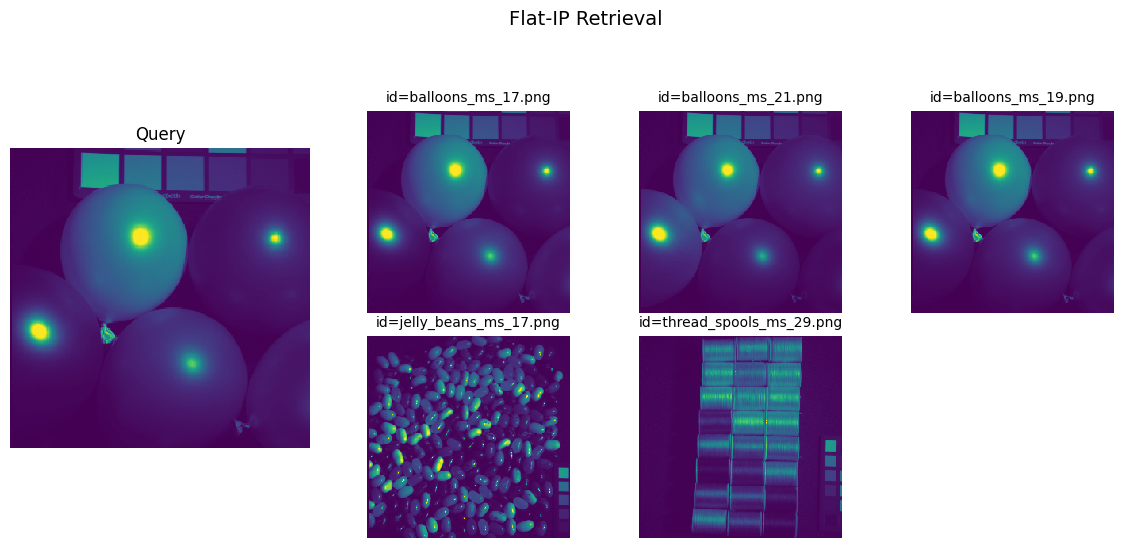

In [3]:
X = np.load("./embedding/embeddings.npy").astype("float32")
ids = load_ids("./embedding/ids.csv")

paths = load_filenames(
    "./embedding/ids.csv",
    base_dirs=[
        "./dataset/train/rgb_images",
        "./dataset/train/ms_masks"
    ],
    prefer_order=("rgb_images", "ms_masks")
)

name_to_path = build_name_to_path(paths)

index = faiss.IndexFlatIP(X.shape[1])
# index = faiss.IndexHNSWFlat(X.shape[1], 32)
index.add(X)

q = X[0:2]

visualize_by_index(
    query_vec=q,
    X=X,
    ids=ids,
    id_to_path=name_to_path,
    index=index,
    topk=5,
    query_image_path=None,
    metric="ip",
    title="Flat-IP Retrieval",
)
